<a href="https://colab.research.google.com/github/TKhahahah/Data_Mining_FinalProject/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.5 MB/s eta 0:00:00


## Library Version 22_4 : Dropout between later, Dense graphs, USe Otograohic precitaiton edges caled from U, W CW, Dem and leedside windside, AttentionLSTM_V8, No Quantile Mapping, adaptive_huber_loss with percentile_loss to handle Extreme Events. Input includes calculated indices: PDO, ONI, SWM, DMI, and downloaded indices: MEIV2, BSISO, and MJO. , NEW NE index


In [2]:
import os
import pandas as pd
import numpy as np
import sys
import datetime
import copy
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
import random
import matplotlib.pyplot as plt
import copy
from dateutil.relativedelta import relativedelta
import time
import inspect
import time as countdown
from tqdm import tqdm
import time as countdown
from torch_geometric.data import HeteroData




import torch
import torch.nn as nn
from torch.nn.parameter import Parameter
import torch.nn.functional as F
from torch.nn import Parameter
from torch import Tensor


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



In [4]:

import os, sys

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Hyperparameters

In [5]:
algo='LSTM_V23_11'

num_epoch = 300
window_size = 24  #Window size
horizon = 12   #Prediction horizon
TBPTT_K = 24

learn_rate =0.001
weight_decay =1e-4
cluster =7 #choose cluster of the HII stations
k_fold_num=2
percentile_loss =0.95

# PARAMETERS FOR SMALL DATA
noise_level = 0.05  # Standard deviation of noise (5% of signal)

min_epochs = 20
patience = 100
LOG_EVERY = 20


hidden_size_list =[128]
num_layers_list =[2]
drop_out_list=[0.4]



## Load dataset

In [6]:
X_index = pd.read_csv('/content/drive/MyDrive/KKU3/X_variable(Index)_operation_v4.csv')
Y_rainfall = pd.read_csv('/content/drive/MyDrive/KKU3/Y_variable(Rainfall).csv')
# Convert 'DATE' column in Y_df to datetime objects if it's not already
X_index['DATE'] = pd.to_datetime(X_index['DATE'])

# Format the dates in Y_df as 'YYYY-MM-01'
X_index['DATE'] = X_index['DATE'].dt.strftime('%Y-%m-01')



node = pd.read_csv('/content/drive/MyDrive/KKU3/Node_table_TMD.csv')


path_feature = os.path.join("/content/drive/MyDrive/KKU3/lookup_table_reanalysis_v5.csv")
feature = pd.read_csv(path_feature, header= "infer")



In [7]:
Y_rainfall = Y_rainfall.rename(columns={'code': 'Node'})

Y_rainfall_clean = Y_rainfall.copy()
num_feature = len(feature[feature['Cluster']==cluster])

In [8]:

def apply_time_lag(df, column_name, lag):
    # Create a new column name with the lag suffix
    new_column_name = f"{column_name}_lag{lag}"

    # Shift the column values by the specified lag
    df[new_column_name] = df[column_name].shift(lag)

    return df

# Define the time lags for each climate index

time_lags = {

    'MEIV2': [1, 2, 3],
    'RMM_AMPLITUDE': [1],
    'PHASE': [1],
    'PDO': [1, 2],
    'ONI': [1, 2],
    'DMI': [1, 2],
    'BSISO1': [1],
    'BSISO1-Phase': [1],
    'SWM': [1],

}




# Apply time lags to each specified column in df_merge_type
for column, lag in time_lags.items():
      if column in X_index.columns:
            for lag_item in lag:
                X_index = apply_time_lag(X_index, column, lag_item)
      else:
        print(f"Warning: Column '{column}' not found in df_merge_type. Skipping.")


Data cleansing

In [9]:
HQ_date_get_month_df  =  Y_rainfall.copy()
Y_rainfall_clean =  Y_rainfall.copy()
HQ_date_get_month_df['DATE'] = pd.to_datetime(Y_rainfall['DATE']).dt.month

month_avg_list = []
for month in range(1, 12 + 1):
    # Filter the data for the current year
    HQ_data = HQ_date_get_month_df[HQ_date_get_month_df['DATE'] == month]

    # Average rainfall
    av_r = HQ_data.iloc[:, 1:].median()

    # Create a dictionary to hold the data for this year
    month_dict = {'MONTH': month}
    month_dict.update(av_r)

    # Append the data for this year to the list
    month_avg_list.append(month_dict)

HQ_month_avg = pd.DataFrame(month_avg_list)

for i in range(1, len(Y_rainfall_clean.columns)):
    for j in range(0, len(Y_rainfall_clean)):
        if(np.isnan(Y_rainfall_clean.iloc[j, i])):
             Y_rainfall_clean.iloc[j, i] = HQ_month_avg.iloc[pd.to_datetime(Y_rainfall_clean.iloc[:, 0]).dt.month[j]-1, i]

In [10]:
Y_rainfall_clean['DATE'].max()

'2025-03-01'

In [11]:
start_training_date = '1982-01-01'


X_index['DATE'] = pd.to_datetime(X_index['DATE'])
Y_rainfall_clean['DATE'] = pd.to_datetime(Y_rainfall_clean['DATE'])
max_date_X = X_index['DATE'].max()
max_date_Y = Y_rainfall_clean['DATE'].max()
# Minimum date possible

print("Maximum date possible : ",start_training_date)


# Maximum date possible
max_date_possible = min([max_date_X,max_date_Y])
print("Maximum date possible : ",max_date_possible)

#Make condition
con_date_X = (X_index['DATE'] >= start_training_date) & (X_index['DATE'] <= max_date_possible)
con_date_Y = (Y_rainfall_clean['DATE'] >= start_training_date) & (Y_rainfall_clean['DATE'] <= max_date_possible)

#Final select
X_index_interval_date = X_index.loc[con_date_X,:]
Y_rainfall_clean = Y_rainfall_clean.loc[con_date_Y,:]


Y_rainfall_interval_date = copy.deepcopy(Y_rainfall_clean)

Maximum date possible :  1982-01-01
Maximum date possible :  2025-03-01 00:00:00


In [12]:
start_training_date = Y_rainfall_clean['DATE'].min()

X_index['DATE'] = pd.to_datetime(X_index['DATE'])
Y_rainfall_clean['DATE'] = pd.to_datetime(Y_rainfall_clean['DATE'])
max_date_X = X_index['DATE'].max()
max_date_Y = Y_rainfall_clean['DATE'].max()
# Minimum date possible

print("Maximum date possible : ",start_training_date)


# Maximum date possible
max_date_possible = min([max_date_X,max_date_Y])
print("Maximum date possible : ",max_date_possible)

#Make condition
con_date_X = (X_index['DATE'] >= start_training_date) & (X_index['DATE'] <= max_date_possible)
con_date_Y = (Y_rainfall_clean['DATE'] >= start_training_date) & (Y_rainfall_clean['DATE'] <= max_date_possible)

#Final select
X_index_interval_date = X_index.loc[con_date_X,:]
Y_rainfall_clean = Y_rainfall_clean.loc[con_date_Y,:]


Y_rainfall_interval_date = copy.deepcopy(Y_rainfall_clean)

Maximum date possible :  1982-01-01 00:00:00
Maximum date possible :  2025-03-01 00:00:00


In [13]:
#Count null value of each indexs
print("Number of index columns which contain null value : ",len(X_index_interval_date.isnull().sum()[X_index_interval_date.isnull().sum()>0]), sep="")
print("Number of rainfall station which contain null value : ",len(Y_rainfall_interval_date.isnull().sum()[Y_rainfall_interval_date.isnull().sum()>0]), sep="")

Number of index columns which contain null value : 0
Number of rainfall station which contain null value : 0


## Convert DATE columns to index columns

In [14]:
def convert_columns_to_index_columns(df,col_name):
    df.loc[:,col_name] = pd.to_datetime(df[col_name])
    df = df.set_index(col_name, inplace=False)
    return df

- independend variable dataframe

In [15]:
X_index_df_ready = convert_columns_to_index_columns(X_index_interval_date, 'DATE')
Y_rainfall_df_ready = convert_columns_to_index_columns(Y_rainfall_interval_date, 'DATE')

In [16]:
print("nrow of X : {}".format(X_index_df_ready.shape[0]))
print("nrow of Y : {}".format(X_index_df_ready.shape[0]))

nrow of X : 519
nrow of Y : 519


## Standardize

In [17]:

#scaler_X = MinMaxScaler()
scaler_X = StandardScaler()

X_normalize_data = scaler_X.fit_transform(X_index_df_ready)
X_index_normalized_df = pd.DataFrame(X_normalize_data, columns=X_index_df_ready.columns)

scaler_Y = StandardScaler()

Y_normalize_data = scaler_Y.fit_transform(Y_rainfall_df_ready)
Y_rainfall_normalized_df = pd.DataFrame(Y_normalize_data, columns=Y_rainfall_df_ready.columns)

In [18]:

# Save the scaler
with open('/content/drive/MyDrive/KKU3/scaler_Y.pkl', 'wb') as file:
    pickle.dump(scaler_Y, file)
# Save the scaler
with open('/content/drive/MyDrive/KKU3/scaler_X.pkl', 'wb') as file:
    pickle.dump(scaler_X, file)


# Load the scaler for inference
with open('/content/drive/MyDrive/KKU3/scaler_Y.pkl', 'rb') as file:
    scaler_Y = pickle.load(file)

## Summarises all climate index

In [19]:
#Get date range from original files because after normalization index will reset
og_date_range = X_index_interval_date['DATE']
X_index_normalized_df.set_index(og_date_range, inplace=True)
Y_rainfall_normalized_df.set_index(og_date_range, inplace=True)

n_feature_climate = X_index_normalized_df.shape[1]
feature_climate = X_index_normalized_df.columns
print("Number of climate index feature : ",n_feature_climate)
print("All climate index : \n",feature_climate)

Number of climate index feature :  24
All climate index : 
 Index(['MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1', 'BSISO1-Phase', 'DMI',
       'ONI', 'PDO', 'SWM', 'NE', 'MEIV2_lag1', 'MEIV2_lag2', 'MEIV2_lag3',
       'RMM_AMPLITUDE_lag1', 'PHASE_lag1', 'PDO_lag1', 'PDO_lag2', 'ONI_lag1',
       'ONI_lag2', 'DMI_lag1', 'DMI_lag2', 'BSISO1_lag1', 'BSISO1-Phase_lag1',
       'SWM_lag1'],
      dtype='object')


## Add cos sin function to X

### Combine static feature

In [20]:
X_index_normalized_df['Month_sin'] = np.sin(2 * np.pi * X_index_normalized_df.index.month / 12)
X_index_normalized_df['Month_cos'] = np.cos(2 * np.pi * X_index_normalized_df.index.month / 12)

In [21]:
station_id_list = Y_rainfall_normalized_df.columns
list_table = []
for code_st in station_id_list:
  #print(code_st)

  #print(static_value)
  eindices_df = X_index_normalized_df.copy()



  eindices_df[code_st] = Y_rainfall_normalized_df[code_st]

  list_table.append(eindices_df)

In [22]:
n_feature_climate = X_index_normalized_df.shape[1]
feature_climate = X_index_normalized_df.columns
print("Number of climate index feature : ",n_feature_climate)
print("All climate index : \n",feature_climate)

Number of climate index feature :  26
All climate index : 
 Index(['MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1', 'BSISO1-Phase', 'DMI',
       'ONI', 'PDO', 'SWM', 'NE', 'MEIV2_lag1', 'MEIV2_lag2', 'MEIV2_lag3',
       'RMM_AMPLITUDE_lag1', 'PHASE_lag1', 'PDO_lag1', 'PDO_lag2', 'ONI_lag1',
       'ONI_lag2', 'DMI_lag1', 'DMI_lag2', 'BSISO1_lag1', 'BSISO1-Phase_lag1',
       'SWM_lag1', 'Month_sin', 'Month_cos'],
      dtype='object')


## Split dataframe to add static feature

### Import meta data

### Add new date and latitude-longitude format columns

## Split training and testing

### Define start and end date of each interval

# Train Fold 1 = 2018-2020, Val = 2018-2020, Test = 2019 - 2021

# Train Fold 2 = 2018-2022, Val = 2021-2023, Test = 1/2022 - 12/2024

In [23]:
#Train interval

start_interval_train1 =  pd.to_datetime(min(Y_rainfall_normalized_df.index))
#maximum_interval_train = max(Y_rainfall_normalized_df.index[0:-6])


end_interval_train1 = start_interval_train1 + relativedelta(months=37*12+11)


#Test1 interval
start_interval_val1 = start_interval_train1 + relativedelta(months=36*12)
end_interval_val1 =  start_interval_train1 + relativedelta(months=38*12+11)



#Test1 interval
start_interval_test1 = start_interval_train1 + relativedelta(months=37*12)
end_interval_test1 = start_interval_train1 + relativedelta(months=39*12+11)
#end_interval_test = start_interval_test + relativedelta(months=backward_months+17)
#Display
print("############################################################")
print("TRAINING Fold 1")
print('Start interval date of training set: ', start_interval_train1)
#print('Maximum interval date : ', maximum_interval_train)
print('End interval date of training set :', end_interval_train1)

print("############################################################")
print("VALIDATION Fold 1")
print('Start interval date of testing set: ', start_interval_val1)
print('End interval date of testing set :', end_interval_val1)
print("############################################################")



print("############################################################")
print("TESTING Fold 1")
print('Start interval date of testing set: ', start_interval_test1)
print('End interval date of testing set :', end_interval_test1)
print("############################################################")
#if cluster in [4 ,5,6,7, 8,9 ,10,11,12]:
#    start_interval_train1 = start_interval_val1 +  relativedelta(months=1)

#    end_interval_train2 = start_interval_train1 +  relativedelta(months=4*12+12)


    #Train interval
#    start_interval_val2 = start_interval_train1 +  relativedelta(months=3*12-1)
#    end_interval_val2 = start_interval_train1 +  relativedelta(months=5*12+10)



    #Test2 interval
#    start_interval_test2 = start_interval_train1 +  relativedelta(months=3*12+9)
#    end_interval_test2 = start_interval_train1 +  relativedelta(months=6*12+11-3)

#else:
start_interval_train1 = start_interval_train1

end_interval_train2 = start_interval_train1 + relativedelta(months=40*12)


    #Train interval
start_interval_val2 = start_interval_train1  + relativedelta(months=39*12)
end_interval_val2 = start_interval_train1 + relativedelta(months=41*12+11)



    #Test2 interval
start_interval_test2 = start_interval_train1 + relativedelta(months=40*12)
end_interval_test2 = start_interval_train1 + relativedelta(months=42*12+11)


#Display
print("############################################################")
print("TRAINING Fold 2")
print('Start interval date of training set: ', start_interval_train1)
#print('Maximum interval date : ', maximum_interval_train)
print('End interval date of training set :', end_interval_train2)

print("############################################################")
print("VALIDATION Fold 2")
print('Start interval date of testing set: ', start_interval_val2)
print('End interval date of testing set :', end_interval_val2)
print("############################################################")



print("############################################################")
print("TESTING Fold 2")
print('Start interval date of testing set: ', start_interval_test2)
print('End interval date of testing set :', end_interval_test2)
print("############################################################")

# Train Fold 1 = 1982-2019, Val = 2018-2020, Test = 2019 - 2021

# Train Fold 2 = 1982-2022, Val = 2021-2023, Test = 2022 - 2024

############################################################
TRAINING Fold 1
Start interval date of training set:  1982-01-01 00:00:00
End interval date of training set : 2019-12-01 00:00:00
############################################################
VALIDATION Fold 1
Start interval date of testing set:  2018-01-01 00:00:00
End interval date of testing set : 2020-12-01 00:00:00
############################################################
############################################################
TESTING Fold 1
Start interval date of testing set:  2019-01-01 00:00:00
End interval date of testing set : 2021-12-01 00:00:00
############################################################
############################################################
TRAINING Fold 2
Start interval date of training set:  1982-01-01 00:00:00
End interval date of training set : 2022-01-01 00:00:00
############################################################
VALIDATION Fold 2
Start interval date of testing set:  2

### Split training and testing

In [24]:
#Split test and train

Train_df_list1, Val_df_list1, Test_df_list1,Train_df_list2,  Val_df_list2 ,Test_df_list2 = [], [],[],[],[],[]
for i_table in range(len(list_table)):
  Train_df_list1.append(list_table[i_table][start_interval_train1:end_interval_train1])
  Val_df_list1.append(list_table[i_table][start_interval_val1:end_interval_val1])
  Test_df_list1.append(list_table[i_table][start_interval_test1:end_interval_test1])
  Train_df_list2.append(list_table[i_table][start_interval_train1:end_interval_train2])
  Val_df_list2.append(list_table[i_table][start_interval_val2:end_interval_val2])
  Test_df_list2.append(list_table[i_table][start_interval_test2:end_interval_test2])

fold =[]
fold.append([Train_df_list1,Test_df_list1,Val_df_list1])
fold.append([Train_df_list2,Test_df_list2,Val_df_list2])


# Feature selection part

## Focus only feature of climate

In [87]:
print("The first feature size that is climate index:", n_feature_climate)

The first feature size that is climate index: 26


In [88]:
selected_index =[]
feature_cluster =  feature[feature['Cluster']==cluster]
for feature_index in range(len(feature_cluster)):
    for i in range(len(feature_climate)):
        if((feature_climate[i] == feature_cluster.iloc[feature_index,1]) and feature_cluster.iloc[feature_index,5] == 0):
                selected_index.append(i)

        elif(feature_cluster.iloc[feature_index,5] != 0):
            for i_lag in range(len(feature_climate)):
                if(feature_climate[i_lag] == feature_cluster.iloc[feature_index,1]+'_lag'+str(feature_cluster.iloc[feature_index,5])):
                    selected_index.append(i_lag)
                    break
                else:
                    continue  # Continue if the inner loop wasn't broken.
            break  # Inner loop was broken, break the outer.

selected_index.sort()
feature_climate[selected_index]


Index(['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'Month_sin',
       'Month_cos'],
      dtype='object')

## Feature selection
- Create binary position (length = climate feature)

In [80]:
random.seed(10)
position_optimal = [0 for i in range(n_feature_climate)]
#position_remain = (Train_df_list[0].shape[1] - n_feature_climate)*[1]
position_remain = [0, 0, 1] # select rain

for id in selected_index:
  position_optimal[id]=1

position_all = position_optimal + position_remain
position_all_index = [index for index,value in enumerate(position_all) if value == 1]
climate_name_list = [feature_climate[index] for index,value in enumerate(position_optimal) if value == 1]

print("position_all_index : ", position_all_index)
print("Climate index : ", climate_name_list)

position_all_index :  [1, 3, 5, 8, 9, 24, 25, 28]
Climate index :  ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'Month_sin', 'Month_cos']


## Select columns by position vector (position_all)

In [89]:
random.seed(10)
position_optimal = [0 for i in range(n_feature_climate)]
#position_remain = (Train_df_list[0].shape[1] - n_feature_climate)*[1]
position_remain = [1] # select rain

for id in selected_index:
  position_optimal[id]=1

position_all = position_optimal + position_remain
position_all_index = [index for index,value in enumerate(position_all) if value == 1]
climate_name_list = [feature_climate[index] for index,value in enumerate(position_optimal) if value == 1]

print("position_all_index : ", position_all_index)
print("Climate index : ", climate_name_list)

position_all_index :  [1, 3, 5, 8, 9, 24, 25, 26]
Climate index :  ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'Month_sin', 'Month_cos']


In [90]:
def select_feature_f(list_df,position_feature_index):
    for i in range(len(list_df)):
        list_df[i] = list_df[i].iloc[:,position_feature_index]
    return list_df

In [91]:
#Fold 1 = Fold[0] , Fold 2 = Fold[1]
#Test Fold 1 = Fold[0][0] , Train Fold 1 = Fold[0][1], Validation Fold 1 = Fold[0][2]
fold[0][0] = select_feature_f(list_df = fold[0][0], position_feature_index = position_all_index)
fold[0][1] = select_feature_f(list_df = fold[0][1], position_feature_index = position_all_index)
fold[0][2] = select_feature_f(list_df = fold[0][2], position_feature_index = position_all_index)
fold[1][0] = select_feature_f(list_df = fold[1][0], position_feature_index = position_all_index)
fold[1][1] = select_feature_f(list_df = fold[1][1], position_feature_index = position_all_index)
fold[1][2] = select_feature_f(list_df = fold[1][2], position_feature_index = position_all_index)

IndexError: positional indexers are out-of-bounds

In [95]:
fold[0][0][1]

,RMM_AMPLITUDE,BSISO1,DMI,SWM,NE,Month_sin,Month_cos,300202
DATE,,,,,,,,
1982-01-01,0.714459,-0.948166,-0.023677,1.469381,1.793781,5.000000e-01,8.660254e-01,-0.981162
1982-02-01,0.281839,-0.948166,1.265857,0.837625,1.758152,8.660254e-01,5.000000e-01,-0.984254
1982-03-01,0.443087,-0.948166,0.981589,0.424145,1.158306,1.000000e+00,6.123234e-17,-0.984254
1982-04-01,0.738476,-0.948166,1.140032,0.264021,1.416414,8.660254e-01,-5.000000e-01,-0.719373
1982-05-01,-0.930963,0.774939,1.531242,-0.468001,0.380173,5.000000e-01,-8.660254e-01,2.381901
...,...,...,...,...,...,...,...,...
2019-08-01,-0.930963,1.268179,2.643234,-0.995432,-1.033522,-8.660254e-01,-5.000000e-01,2.422097
2019-09-01,-0.930963,0.932615,3.007009,-1.467186,-1.029036,-1.000000e+00,-1.836970e-16,-0.385437
2019-10-01,-0.930963,0.717530,4.054789,-1.652670,-0.257663,-8.660254e-01,5.000000e-01,-0.434909


In [31]:
len(Y_rainfall_normalized_df.columns)

132

## Read node location

In [66]:
cluster_station= []
for index in range(0,lenhttps://colab.research.google.com/drive/17rmZzC6-fdMrsBJuY6IehUCpWdb6jxyJ?authuser=1#scrollTo=Check_edges(Y_rainfall_normalized_df.columns)):
    if (node['quality'].iloc[index]==1 and node['cluster'].iloc[index]==cluster) :
            cluster_station.append(index)


In [67]:
for index in range(len(cluster_station)):
    print(node['Node'].iloc[cluster_station[index]])

300201
300202
303201
303301
327501
328201
331201
331301
331401


Create node

Creat training test set for each station

Create static features

In [62]:
num_feature = len(feature[feature['Cluster']==cluster])

## Check edges

In [35]:

def extract_features(feature,j, window_size,horizon,data_list):
    xs_list= []
    for station in cluster_station:
        xs_new= np.array(data_list[station].iloc[:,feature][j:j+window_size])
        xs_list.append([xs_new])
    xs = np.array(xs_list)
    return xs

In [36]:
climate_name_list

['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'Month_sin', 'Month_cos']

In [64]:
num_feature

7

In [92]:
fold[0][0]

[            RMM_AMPLITUDE    BSISO1       DMI       SWM        NE  \
 DATE                                                                
 1982-01-01       0.714459 -0.948166 -0.023677  1.469381  1.793781   
 1982-02-01       0.281839 -0.948166  1.265857  0.837625  1.758152   
 1982-03-01       0.443087 -0.948166  0.981589  0.424145  1.158306   
 1982-04-01       0.738476 -0.948166  1.140032  0.264021  1.416414   
 1982-05-01      -0.930963  0.774939  1.531242 -0.468001  0.380173   
 ...                   ...       ...       ...       ...       ...   
 2019-08-01      -0.930963  1.268179  2.643234 -0.995432 -1.033522   
 2019-09-01      -0.930963  0.932615  3.007009 -1.467186 -1.029036   
 2019-10-01      -0.930963  0.717530  4.054789 -1.652670 -0.257663   
 2019-11-01       1.058389 -0.948166  3.547012 -0.585071  0.857334   
 2019-12-01       0.323061 -0.948166  1.588506  0.643445  1.242208   
 
                Month_sin     Month_cos    300201  
 DATE                               

In [65]:
Y_rainfall_normalized_df

,300201,300202,303201,303301,310201,327202,327301,327501,328201,328202,...,566202,567201,568301,568401,568501,568502,570201,580201,581301,583201
DATE,,,,,,,,,,,,,,,,,,,,,
1982-01-01,-1.001187,-0.981162,-0.953483,-0.935345,-1.025942,-1.027339,-0.965886,-0.969568,-0.971742,-0.940612,...,-1.196874,-1.363819,-1.052482,-0.977540,-0.730869,-1.127867,-1.446425,-0.952991,-1.147741,-0.870208
1982-02-01,-1.019505,-0.984254,-0.993675,-0.997438,-1.042255,-1.127137,-0.965886,-0.969568,-0.982634,-1.025930,...,-1.408872,-1.365285,-0.822926,-1.272590,-0.869828,-1.113180,-1.406489,-0.932629,-1.145926,-0.838260
1982-03-01,-1.019505,-0.984254,-0.978162,-0.899125,-1.007453,-0.994672,-0.957489,-0.969568,-0.912925,-0.941177,...,-0.853229,-0.813800,-0.517444,-0.819642,-0.698542,-0.112163,-1.076651,-0.945804,-0.810033,-0.882496
1982-04-01,-0.718704,-0.719373,0.020302,0.155706,1.442864,-0.501068,0.041814,-0.425223,-0.598145,-0.156928,...,-0.376574,0.081629,-0.550662,0.055134,0.119291,0.258097,1.281023,-0.018153,-0.277445,-0.723985
1982-05-01,0.702392,2.381901,-0.159506,0.082525,0.207374,0.500499,1.732112,0.335635,0.444225,1.158441,...,0.335230,1.265269,0.384172,-0.250865,-0.292761,0.736575,1.270669,-0.173260,0.315058,-0.250091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-01,-0.112280,-0.357609,-0.816688,-0.785289,-0.858454,-0.317986,-0.691168,-0.487521,-0.844305,-0.643976,...,-0.698884,1.733151,4.277138,4.881965,5.617349,4.415216,0.481573,7.433003,6.066396,5.817146
2024-12-01,-0.901884,-0.984254,-0.775085,-0.699542,-0.726857,-0.999338,-0.954490,-0.847014,-0.967385,-1.065482,...,-1.223658,-0.953872,0.463063,-0.283712,0.897077,-0.075833,-1.202374,0.763374,0.188569,0.716948
2025-01-01,-1.019505,-0.984254,-0.993675,-0.995959,-1.042255,-1.127137,-0.965886,-0.969568,-0.982634,-1.065482,...,-1.499663,-1.092476,0.009883,-0.002493,-0.234862,-0.193327,-1.003436,-0.267882,-0.082567,0.789855


## Linear Regression

In [49]:
# เลือกสถานีที่ 1 ใน Cluster มาทดสอบ
station_idx = cluster_station[0]
station_name = node['Node'].iloc[station_idx]

# ดึงข้อมูลน้ำฝน (Y) ที่ถูก Normalize แล้วจากตัวแปรของพี่เขา
y_all = Y_rainfall_normalized_df.iloc[:, station_idx]

print(f"กำลังเตรียมข้อมูลสำหรับสถานี: {station_name}")

กำลังเตรียมข้อมูลสำหรับสถานี: 300201


In [52]:
# 1. ดึง X จาก Fold 0 (ตามโครงสร้าง fold[0] = [Train_df_list1, Test_df_list1, Val_df_list1])
# ดังนั้น fold[0][0] คือ training dataframes list, fold[0][1] คือ testing dataframes list

X_train_df_for_station = fold[0][0][station_idx] # Get the training DataFrame for the specific station
X_test_df_for_station = fold[0][1][station_idx]  # Get the testing DataFrame for the specific station

# 2. จับคู่ Y ให้ตรงกับวันที่ (index) ของ X ในแต่ละชุด
# ใช้ .loc เพื่อ index ด้วย DatetimeIndex
y_train = y_all.loc[X_train_df_for_station.index]
y_test = y_all.loc[X_test_df_for_station.index]

# 3. กำจัดค่าว่าง (NaN) เพื่อไม่ให้โมเดล Linear Regression รันไม่ได้
train_mask = ~y_train.isna()
test_mask = ~y_test.isna()

# Apply masks to the respective DataFrames and Series
X_train, y_train = X_train_df_for_station[train_mask], y_train[train_mask]
X_test, y_test = X_test_df_for_station[test_mask], y_test[test_mask]

print(f"แบ่งชุดข้อมูลเสร็จสิ้น: Train {len(X_train)} เดือน, Test {len(X_test)} เดือน")

แบ่งชุดข้อมูลเสร็จสิ้น: Train 456 เดือน, Test 36 เดือน


In [53]:
from sklearn.linear_model import LinearRegression

# 1. สร้างตัวโมเดล
lr_model = LinearRegression()

# 2. ให้โมเดลเรียนรู้ (Fit)
lr_model.fit(X_train, y_train)

print(f"✅ ขั้นตอนที่ 3 สำเร็จ: โมเดลเรียนรู้สถานี {station_name} เรียบร้อยแล้ว")

✅ ขั้นตอนที่ 3 สำเร็จ: โมเดลเรียนรู้สถานี 300201 เรียบร้อยแล้ว


In [54]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. พยากรณ์ค่าจากชุด Test (36 เดือนที่เราแยกไว้)
y_pred = lr_model.predict(X_test)

# 2. คำนวณค่า R-squared, RMSE และ MAE
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("\n" + "="*40)
print(f"📊 สรุปผลความแม่นยำสถานี: {station_name}")
print(f"✅ R-squared (R²): {r2:.4f}")
print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAE: {mae:.4f}")
print("="*40)


📊 สรุปผลความแม่นยำสถานี: 300201
✅ R-squared (R²): 1.0000
✅ RMSE: 0.0000
✅ MAE: 0.0000


In [55]:
# เช็คว่ามีคอลัมน์ไหนหน้าตาเหมือนคำตอบหลุดเข้าไปไหม
print("รายชื่อปัจจัย (Features) ที่โมเดลใช้:")
print(X_train.columns.tolist())

# เช็คว่าข้อมูล X กับ y มันคืออันเดียวกันหรือเปล่า
print(f"\nความสัมพันธ์เบื้องต้น: {X_train.iloc[:,0].corr(y_train)}")

รายชื่อปัจจัย (Features) ที่โมเดลใช้:
['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'Month_sin', 'Month_cos', '300201']

ความสัมพันธ์เบื้องต้น: -0.7612312388181988


In [58]:
# --- ขั้นตอนที่ 2 (แก้ไขเข้าถึง List) ---

# 1. ดึง DataFrame ออกมาจาก List (fold[0][0] คือ Train, fold[0][1] คือ Test)
X_train_df = fold[0][0][station_idx] # Get the training DataFrame for the specific station
X_test_df = fold[0][1][station_idx]  # Get the testing DataFrame for the specific station

# 2. คัดเลือกเฉพาะคอลัมน์ที่ไม่ใช่ "ชื่อสถานี"
# ตรวจสอบว่ามีชื่อสถานี '300201' หรือชื่ออื่นๆ แฝงใน Columns หรือไม่
exclude_cols = [str(station_name), '300201']
features_to_use = [col for col in X_train_df.columns if col not in exclude_cols]

X_train_clean = X_train_df[features_to_use]
X_test_clean = X_test_df[features_to_use]

# 3. จับคู่ Y และจัดการ NaN
y_train_raw = y_all.reindex(X_train_clean.index)
y_test_raw = y_all.reindex(X_test_clean.index)

train_mask = ~y_train_raw.isna()
test_mask = ~y_test_raw.isna()

X_train = X_train_clean[train_mask]
y_train = y_train_raw[train_mask]
X_test = X_test_clean[test_mask]
y_test = y_test_raw[test_mask]

print(f"✅ คลีนข้อมูลและดึงจาก List สำเร็จ!")
print(f"รายชื่อปัจจัยที่ใช้จริง: {X_train.columns.tolist()}")

✅ คลีนข้อมูลและดึงจาก List สำเร็จ!
รายชื่อปัจจัยที่ใช้จริง: ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'Month_sin', 'Month_cos']


In [59]:
from sklearn.linear_model import LinearRegression

# 1. สร้างตัวโมเดล
lr_model = LinearRegression()

# 2. ฝึกสอน (Fit) ด้วยข้อมูลที่ไม่มีเฉลยปน
lr_model.fit(X_train, y_train)

print(f"✅ ขั้นตอนที่ 3 สำเร็จ: โมเดลเรียนรู้จากปัจจัยภูมิอากาศเรียบร้อยแล้ว")

✅ ขั้นตอนที่ 3 สำเร็จ: โมเดลเรียนรู้จากปัจจัยภูมิอากาศเรียบร้อยแล้ว


In [60]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. พยากรณ์ 36 เดือนล่าสุด
y_pred = lr_model.predict(X_test)

# 2. คำนวณค่าสถิติ
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n" + "="*40)
print(f"📊 สรุปผลความแม่นยำที่แท้จริง (สถานี: {station_name})")
print(f"✅ R-squared (R²): {r2:.4f}")
print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAE: {mae:.4f}")
print("="*40)


📊 สรุปผลความแม่นยำที่แท้จริง (สถานี: 300201)
✅ R-squared (R²): 0.5501
✅ RMSE: 0.6824
✅ MAE: 0.5077


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, 

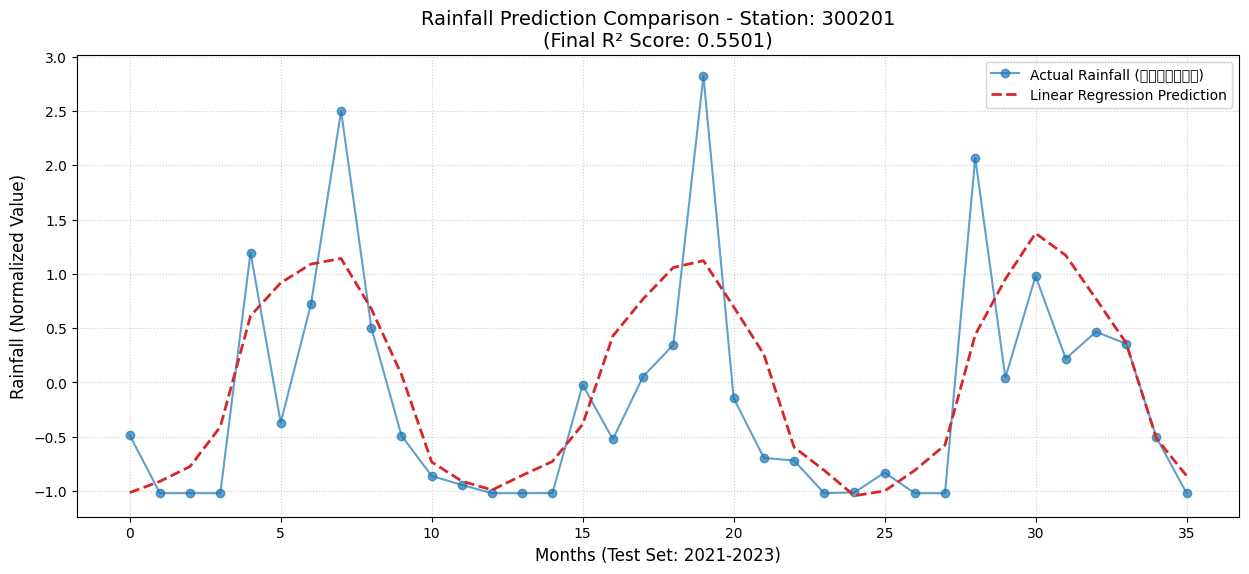

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

# 1. พลอตค่าจริง (Actual)
plt.plot(range(len(y_test)), y_test.values, label='Actual Rainfall (ค่าจริง)', color='#1f77b4', marker='o', alpha=0.7)

# 2. พลอตค่าพยากรณ์จาก Linear Regression
plt.plot(range(len(y_pred)), y_pred, label='Linear Regression Prediction', color='#d62728', linestyle='--', linewidth=2)

plt.title(f'Rainfall Prediction Comparison - Station: {station_name}\n(Final R² Score: {r2:.4f})', fontsize=14)
plt.xlabel('Months (Test Set: 2021-2023)', fontsize=12)
plt.ylabel('Rainfall (Normalized Value)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [97]:
results = []

# วนลูปทำให้ครบทุกสถานีใน Cluster ของนาย
for i, station_idx in enumerate(cluster_station):
    station_name = node['Node'].iloc[station_idx]

    # 1. เตรียมข้อมูล X, y (ใช้ Logic ที่เราแก้กันจนสำเร็จ)
    X_train_df = fold[0][0][i]
    X_test_df = fold[0][1][i]

    exclude_cols = [str(station_name), '300201', '300202', '303201', '303301', '327501', '328201', '331201', '331301', '331401']
    features_to_use = [col for col in X_train_df.columns if col not in exclude_cols]

    X_train_clean = X_train_df[features_to_use]
    X_test_clean = X_test_df[features_to_use]

    y_all = Y_rainfall_normalized_df.iloc[:, station_idx]
    y_train = y_all.reindex(X_train_clean.index).dropna()
    y_test = y_all.reindex(X_test_clean.index).dropna()

    X_train = X_train_clean.loc[y_train.index]
    X_test = X_test_clean.loc[y_test.index]

    # 2. ฝึกสอนและพยากรณ์
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # 3. เก็บผลลัพธ์
    r2 = r2_score(y_test, y_pred)
    results.append({'Station': station_name, 'R-squared': r2})

# แสดงผลสรุปเป็นตาราง
df_summary = pd.DataFrame(results)
print(df_summary)

   Station  R-squared
0   300201   0.550086
1   300202   0.574402
2   303201   0.598917
3   303301   0.616560
4   327501   0.609864
5   328201   0.589569
6   331201   0.564322
7   331301   0.450407
8   331401   0.534255
